# 04 — Feature Engineering
**Project:** Telco Customer Churn Prediction  
**Author:** Udit Jadli  
**Dataset:** Maven Analytics — Telecom Customer Churn  

## Objective
Transform the raw dataset into a clean, numeric, model-ready format by handling 
missing values, encoding categorical variables, scaling numeric features, and 
addressing class imbalance using SMOTE.

## 1. Imports
We import all libraries needed for data manipulation, encoding, scaling, and SMOTE.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

# consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data
We reload the raw dataset and recreate the binary Churn column. 
We start from the raw file each time to ensure this notebook is 
fully reproducible and independent of previous notebooks.

In [2]:
# load raw data
DATA_RAW = os.path.join('..', 'data', 'raw')
df = pd.read_csv(os.path.join(DATA_RAW, 'telecom_customer_churn.csv'), encoding='latin-1')

# recreate binary churn column — 1 = churned, 0 = stayed or joined
df['Churn'] = (df['Customer Status'] == 'Churned').astype(int)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn rate: {df['Churn'].mean() * 100:.1f}%")

Dataset loaded: 7,043 rows × 39 columns
Churn rate: 26.5%


## 3. Drop Irrelevant Columns
We remove columns that should not be used as ML features — either because 
they are identifiers, leakage risks, or post-churn outcome columns that 
would not be available at prediction time.

In [3]:
# columns to drop and why
cols_to_drop = [
    'Customer ID',       # unique identifier — carries no predictive signal
    'Customer Status',   # source of our target variable — would cause leakage
    'Churn Category',    # only available after churn occurs — leakage
    'Churn Reason',      # only available after churn occurs — leakage
    'Latitude',          # zip code already captures geography
    'Longitude',         # zip code already captures geography
    'City',              # too granular — 1,000+ unique cities
]

df = df.drop(columns=cols_to_drop)

print(f"Columns after dropping: {df.shape[1]}")
print(f"\nRemaining columns:\n{list(df.columns)}")

Columns after dropping: 32

Remaining columns:
['Gender', 'Age', 'Married', 'Number of Dependents', 'Zip Code', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Churn']


## 4. Handle Missing Values
We fill missing values using business logic rather than statistical imputation. 
Each group of nulls has a specific reason for being missing, so each gets a 
meaningful fill value that reflects the underlying business context.

In [4]:
# group 1 — internet-related columns (null = no internet service)
internet_cols = [
    'Internet Type', 'Avg Monthly GB Download', 'Online Security',
    'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data'
]
for col in internet_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('No Internet Service')
    else:
        df[col] = df[col].fillna(0)

# group 2 — phone-related columns (null = no phone service)
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)
df['Multiple Lines'] = df['Multiple Lines'].fillna('No Phone Service')

# group 3 — offer column (null = no offer accepted)
df['Offer'] = df['Offer'].fillna('No Offer')

# verify no nulls remain
remaining_nulls = df.isnull().sum().sum()
print(f"Total missing values remaining: {remaining_nulls}")
print("All missing values handled." if remaining_nulls == 0 else "Some nulls remain — investigate.")

Total missing values remaining: 0
All missing values handled.


## 5. Encode Categorical Variables
We convert all text columns into numbers so ML models can process them. 
We use two encoding strategies depending on the column type:
- **Binary columns** (Yes/No) → Label encoding (0 and 1)
- **Multi-category columns** (Contract, Internet Type etc.) → One-hot encoding (separate 0/1 column per category)

In [5]:
# binary columns — simple Yes/No or two-value columns
# these get label encoded: Yes → 1, No → 0
binary_cols = [
    'Gender', 'Married', 'Phone Service', 'Multiple Lines',
    'Internet Service', 'Online Security', 'Online Backup',
    'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
    'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Paperless Billing'
]

# map Yes/No and Female/Male to 1/0
binary_map = {
    'Yes': 1, 'No': 0,
    'Female': 1, 'Male': 0,
    'No Internet Service': 0,
    'No Phone Service': 0
}

for col in binary_cols:
    df[col] = df[col].map(binary_map)

print("Binary columns encoded:")
print(df[binary_cols].head(3))

Binary columns encoded:
   Gender  Married  Phone Service  Multiple Lines  Internet Service  \
0       1        1              1               0                 1   
1       0        0              1               1                 1   
2       0        0              1               0                 1   

   Online Security  Online Backup  Device Protection Plan  \
0                0              1                       0   
1                0              0                       0   
2                0              0                       1   

   Premium Tech Support  Streaming TV  Streaming Movies  Streaming Music  \
0                     1             1                 0                0   
1                     0             0                 1                1   
2                     0             0                 0                0   

   Unlimited Data  Paperless Billing  
0               1                  1  
1               0                  0  
2               1       

### One-hot encoding for multi-category columns
For columns with more than two categories, we create a separate binary column 
for each category. `drop_first=True` drops one category per column to avoid 
multicollinearity — the dropped category becomes the baseline reference.

In [6]:
# multi-category columns — each gets one-hot encoded
multi_cat_cols = [
    'Offer',
    'Internet Type',
    'Contract',
    'Payment Method'
]

# drop_first=True avoids multicollinearity (dummy variable trap)
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print(f"Columns after one-hot encoding: {df.shape[1]}")
print(f"\nNew columns created:")
new_cols = [c for c in df.columns if any(c.startswith(m) for m in multi_cat_cols)]
for col in new_cols:
    print(f"  {col}")

Columns after one-hot encoding: 40

New columns created:
  Offer_Offer A
  Offer_Offer B
  Offer_Offer C
  Offer_Offer D
  Offer_Offer E
  Internet Type_DSL
  Internet Type_Fiber Optic
  Internet Type_No Internet Service
  Contract_One Year
  Contract_Two Year
  Payment Method_Credit Card
  Payment Method_Mailed Check


## 6. Feature & Target Split
We separate the dataset into features (X) and target (y), then split 
into training and test sets. We use stratified splitting to ensure 
both sets have the same churn rate as the full dataset.

In [7]:
# separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nClass distribution in full dataset:")
print(f"  Not churned: {(y == 0).sum():,} ({(y == 0).mean() * 100:.1f}%)")
print(f"  Churned:     {(y == 1).sum():,} ({(y == 1).mean() * 100:.1f}%)")

Features shape: (7043, 39)
Target shape:   (7043,)

Class distribution in full dataset:
  Not churned: 5,174 (73.5%)
  Churned:     1,869 (26.5%)


### Train/Test Split
We split the data 80/20 — 80% for training the models, 20% held back for 
final evaluation. Stratified splitting ensures both sets maintain the same 
26.5% churn rate as the full dataset.

In [8]:
# stratified 80/20 split — random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,      # fixed seed — same split every time notebook runs
    stratify=y            # maintain churn rate in both sets
)

print(f"Training set:  {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nChurn rate in training set: {y_train.mean() * 100:.1f}%")
print(f"Churn rate in test set:     {y_test.mean() * 100:.1f}%")

Training set:  5,634 rows (80.0%)
Test set:      1,409 rows (20.0%)

Churn rate in training set: 26.5%
Churn rate in test set:     26.5%


## 7. Scale Numeric Features
We standardise numeric features so they all have a mean of 0 and 
standard deviation of 1. This prevents features with large ranges 
(like Total Charges: $18–$8,684) from dominating features with 
small ranges (like Tenure: 1–72 months).

Important: we fit the scaler on training data only, then apply it 
to both train and test sets — this prevents data leakage.

In [9]:
# numeric columns to scale
numeric_cols = [
    'Age', 'Number of Dependents', 'Zip Code', 'Number of Referrals',
    'Tenure in Months', 'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges',
    'Total Refunds', 'Total Extra Data Charges',
    'Total Long Distance Charges', 'Total Revenue'
]

scaler = StandardScaler()

# fit on training data only — never fit on test data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# apply the same scaler to test data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Numeric features scaled successfully.")
print(f"\nSample — Monthly Charge after scaling:")
print(f"  Mean:  {X_train['Monthly Charge'].mean():.4f} (should be ~0)")
print(f"  Std:   {X_train['Monthly Charge'].std():.4f} (should be ~1)")

Numeric features scaled successfully.

Sample — Monthly Charge after scaling:
  Mean:  -0.0000 (should be ~0)
  Std:   1.0001 (should be ~1)


## 8. Handle Class Imbalance with SMOTE
With 73.5% not-churned vs 26.5% churned, a naive model could achieve 
73.5% accuracy by predicting "not churned" every time — without learning 
anything useful. SMOTE (Synthetic Minority Oversampling Technique) creates 
synthetic churned customer examples to balance the classes.

Important: SMOTE is applied to training data only — never to test data. 
The test set must reflect real-world class distribution.

In [10]:
# check class distribution before SMOTE
print("Before SMOTE:")
print(f"  Not churned: {(y_train == 0).sum():,} ({(y_train == 0).mean() * 100:.1f}%)")
print(f"  Churned:     {(y_train == 1).sum():,} ({(y_train == 1).mean() * 100:.1f}%)")

# apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# check class distribution after SMOTE
print(f"\nAfter SMOTE:")
print(f"  Not churned: {(y_train_sm == 0).sum():,} ({(y_train_sm == 0).mean() * 100:.1f}%)")
print(f"  Churned:     {(y_train_sm == 1).sum():,} ({(y_train_sm == 1).mean() * 100:.1f}%)")
print(f"\nTraining set size: {len(X_train):,} → {len(X_train_sm):,} rows after SMOTE")

Before SMOTE:
  Not churned: 4,139 (73.5%)
  Churned:     1,495 (26.5%)

After SMOTE:
  Not churned: 4,139 (50.0%)
  Churned:     4,139 (50.0%)

Training set size: 5,634 → 8,278 rows after SMOTE


## 9. Visualise Class Balance
We visualise the class distribution before and after SMOTE to confirm 
the balancing worked correctly.

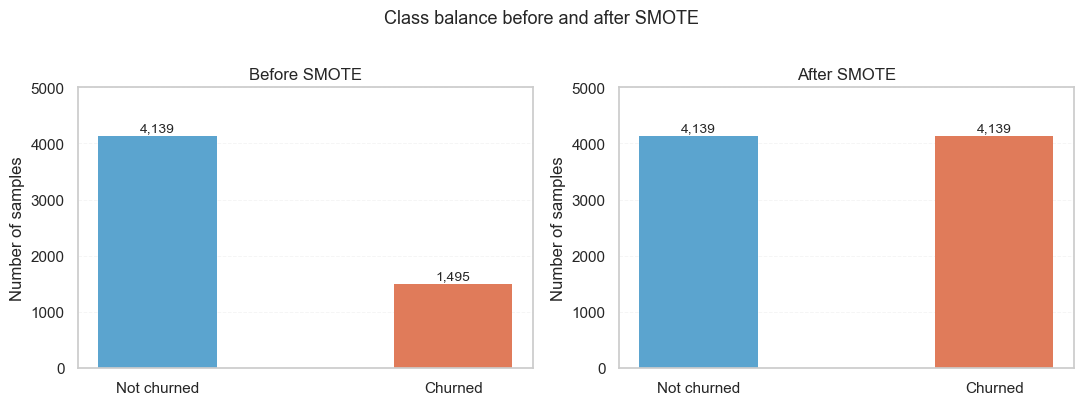

Saved → reports/figures/04_smote_balance.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# before SMOTE
axes[0].bar(['Not churned', 'Churned'],
            [y_train.value_counts()[0], y_train.value_counts()[1]],
            color=['#5BA4CF', '#E07B5A'], edgecolor='none', width=0.4)
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Number of samples')
axes[0].set_ylim(0, 5000)
axes[0].set_axisbelow(True)
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
axes[0].xaxis.grid(False)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 80,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontsize=10)

# after SMOTE
axes[1].bar(['Not churned', 'Churned'],
            [sum(y_train_sm == 0), sum(y_train_sm == 1)],
            color=['#5BA4CF', '#E07B5A'], edgecolor='none', width=0.4)
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Number of samples')
axes[1].set_ylim(0, 5000)
axes[1].set_axisbelow(True)
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.2)
axes[1].xaxis.grid(False)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 80,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontsize=10)

plt.suptitle('Class balance before and after SMOTE', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/04_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → reports/figures/04_smote_balance.png")

**Finding:** SMOTE created 2,644 synthetic churned customer examples, 
balancing the training set from 73.5%/26.5% to a perfect 50%/50% split. 
The test set remains untouched at the natural 26.5% churn rate — 
reflecting real-world class distribution for honest model evaluation.

## 10. Export Processed Data
We save the processed train and test sets to data/processed/ so the 
modelling notebook can load them directly without repeating all 
preprocessing steps.

In [12]:
import os

# create processed directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# save all four sets
X_train_sm.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)

pd.Series(y_train_sm, name='Churn').to_csv('../data/processed/y_train.csv', index=False)
pd.Series(y_test, name='Churn').to_csv('../data/processed/y_test.csv', index=False)

print(" X_train.csv saved — SMOTE balanced training features ")
print(f"  Shape: {X_train_sm.shape}")
print("\n X_test.csv saved — original test features ")
print(f"  Shape: {X_test.shape}")
print("\n y_train.csv saved — SMOTE balanced training labels ")
print(f"  Shape: {y_train_sm.shape}")
print("\n y_test.csv saved — original test labels")
print(f"  Shape: {y_test.shape}")

 X_train.csv saved — SMOTE balanced training features 
  Shape: (8278, 39)

 X_test.csv saved — original test features 
  Shape: (1409, 39)

 y_train.csv saved — SMOTE balanced training labels 
  Shape: (8278,)

 y_test.csv saved — original test labels
  Shape: (1409,)


## Summary

| Step | Action | Result |
|---|---|---|
| Drop columns | Removed 7 irrelevant/leakage columns | 38 → 32 columns |
| Handle nulls | Business-logic fill for all 15 null columns | 0 nulls remaining |
| Binary encoding | Label encoded 14 Yes/No columns | All → 0 or 1 |
| One-hot encoding | Encoded 4 multi-category columns | 32 → 40 columns |
| Train/test split | Stratified 80/20 split | 5,634 train / 1,409 test |
| Scaling | StandardScaler on 13 numeric columns | Mean ~0, Std ~1 |
| SMOTE | Balanced minority class in training set | 5,634 → 8,278 rows |
| Export | Saved 4 processed files to data/processed/ | Ready for modelling |

## Next step
`05_modelling.ipynb` — train Logistic Regression, Random Forest, 
and XGBoost models, compare performance, and explain predictions with SHAP.